# Mini ML Project – Student Performance Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = {
    "StudyHours": [1,2,3,4,5,6,7,8,2,3,5,6],
    "Attendance": [50,60,65,70,75,80,85,90,55,60,78,88],
    "Pass": [0,0,0,1,1,1,1,1,0,0,1,1]
}

df = pd.DataFrame(data)
print(df)

    StudyHours  Attendance  Pass
0            1          50     0
1            2          60     0
2            3          65     0
3            4          70     1
4            5          75     1
5            6          80     1
6            7          85     1
7            8          90     1
8            2          55     0
9            3          60     0
10           5          78     1
11           6          88     1


In [3]:
X = df[["StudyHours", "Attendance"]]
y = df["Pass"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [6]:
y_pred = model.predict(X_test)
print("Predictions:", y_pred)

Predictions: [1 0 0]


In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



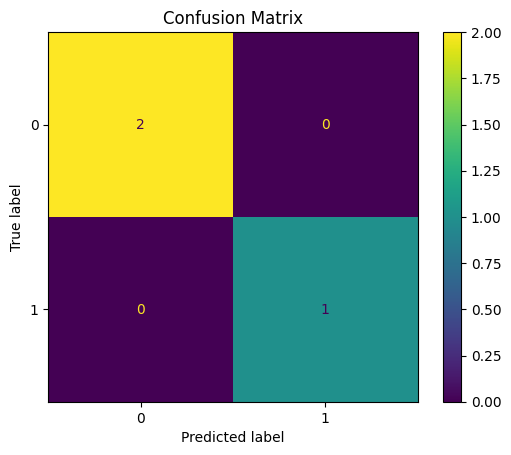

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

In [9]:
def predict_pass(study_hours, attendance):
    input_data = np.array([[study_hours, attendance]])
    prediction = model.predict(input_data)

    if prediction[0] == 1:
        return "Pass"
    else:
        return "Fail"

# Test it
print(predict_pass(6, 80))

Pass


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


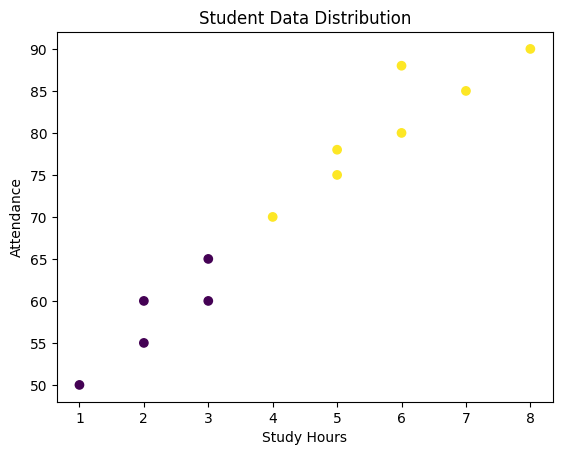

In [10]:
plt.scatter(df["StudyHours"], df["Attendance"], c=df["Pass"])
plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("Student Data Distribution")
plt.show()

## Conclusion

- Logistic Regression successfully predicted student performance
- Study hours and attendance are important factors
- Model can be used for basic prediction system